# DISS-Metrik: comparison walkthrough

A guided tour of the 5 metrics developed in this dissertation, run against a single example
comparison pair (`LabTracker` model, `0shot` LLM setting) and then summarised across the whole dataset.

**This notebook is hybrid:**
- the top section loads the pre-computed `Results/results_metrikN.json` and `Results/metrics_comparison.json` files (~5 seconds).
- the bottom section contains a *live* cell that re-runs all 5 metrics on the example pair (~2 minutes; gated by a flag).

To reproduce everything from scratch, see `../RunMetrics/README.md`.


## 1. Setup


In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib
matplotlib.use("Agg")  # non-interactive backend; works headless
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Resolve paths relative to this notebook.
NB_DIR = Path.cwd().resolve()
# When run from the notebook, NB_DIR is Quantitative-Analysis/Notebooks/.
QA_DIR = NB_DIR.parent
PROJECT_ROOT = QA_DIR.parent
DATASET_PATH = QA_DIR / "Dataset" / "combined-data.json"
RESULTS_DIR = QA_DIR / "Results"
WORKFLOW_DIR = QA_DIR / "Workflow"
WORKFLOWS_DIR = QA_DIR / "RunMetrics"
METRIC_DIR = PROJECT_ROOT / "Metric-Implementation"

# Add the Workflow package and the Workflows helpers to sys.path.
sys.path.insert(0, str(QA_DIR))
sys.path.insert(0, str(WORKFLOWS_DIR))

print(f"Notebook dir:        {NB_DIR}")
print(f"Project root:        {PROJECT_ROOT}")
print(f"Dataset:             {DATASET_PATH}")
print(f"Results:             {RESULTS_DIR}")


Notebook dir:        /Users/vasiliy/Documents/GitHub/diss-metrik/Quantitative-Analysis/Notebooks
Project root:        /Users/vasiliy/Documents/GitHub/diss-metrik
Dataset:             /Users/vasiliy/Documents/GitHub/diss-metrik/Quantitative-Analysis/Dataset/combined-data.json
Results:             /Users/vasiliy/Documents/GitHub/diss-metrik/Quantitative-Analysis/Results


## 2. The dataset

8 domain models × 5 LLM prompting settings = **39 comparison pairs**.
Each pair has the human-evaluated precision/recall/F1 for Class, Attribute, Association.


In [2]:
from Workflow import DataLoader

loader = DataLoader(dataset_path=str(DATASET_PATH))
loader.load()
print(f"Total comparisons: {loader.total_comparisons}")
print(f"Models:    {loader.models}")
print(f"Settings:  {loader.settings}")


Total comparisons: 39
Models:    ['LabTracker', 'CelO', 'TSS', 'SHAS', 'OTS', 'Block', 'TileO', 'HBMS']
Settings:  ['0shot', '1shot_BTMS', '1shot_H2S', '2shots', 'CoT']


## 3. Pick one example pair

We'll use **`LabTracker` / `0shot`** as the running example. The reference is a hand-curated class
diagram of a lab-requisition management system; the generated is an LLM-produced version with
zero-shot prompting.


In [3]:
example = next(c for c in loader.iter_comparisons() if c.comparison_id == "LabTracker_0shot")
print(f"Comparison: {example.comparison_id}")
print(f"Model:      {example.model_full_name}")
print(f"Setting:    {example.setting}")
print()
print("Reference PlantUML (first 400 chars):")
print(example.reference_plantuml[:400] + "…")
print()
print("Generated PlantUML (first 400 chars):")
print(example.generated_plantuml[:400] + "…")
print()
print("Human F1 scores:")
for elem in ("Class", "Attribute", "Association"):
    m = example.human_metrics.get(elem, {})
    print(f"  {elem:12s}  P={m.get('precision', '?'):.3f}  R={m.get('recall', '?'):.3f}  F1={m.get('f1', '?'):.3f}")


Comparison: LabTracker_0shot
Model:      Lab Requisition Management System
Setting:    0shot

Reference PlantUML (first 400 chars):
@startuml

enum Interval {
    weekly
    monthly
    everyHalfYear
    yearly
}

enum AccessType {
    reservable
    walkIn
    dropOff
}

enum DayOfWeek {
    Monday
    Tuesday
    Wednesday
    Thursday
    Friday
    Saturday
    Sunday
}

abstract class PersonRole {
    idNumber
}

class Person {
    lastName
    firstName
    address
    phoneNumber
}

class Patient {
    dateOfBirth
}

cl…

Generated PlantUML (first 400 chars):
@startuml

' Enumerations
enum RepetitionInterval {
    WEEKLY
    MONTHLY
    HALF_YEARLY
    YEARLY
}

enum TestResult {
    NEGATIVE
    POSITIVE
}

' Classes
class Doctor {
    practitionerNumber : Integer
    fullName : String
    address : String
    phoneNumber : String
    digitalSignature : Image
}

class Patient {
    healthNumber : String
    firstName : String
    lastName : String
   …

Human F1 scores:
  Class

## 4. The 5 metric scores (pre-computed)

Each metric produces 3 scores in [0.0, 1.0] for Class, Attribute, Association.
The `Results/results_metrikN.json` files were generated by the workflows in `RunMetrics/`.


In [4]:
metric_results = {}
for n in (1, 2, 3, 4, 5):
    p = RESULTS_DIR / f"results_metrik{n}.json"
    data = json.loads(p.read_text())
    c = data["comparisons"]["LabTracker_0shot"]
    metric_results[f"Metrik-{n}"] = c["metric_results"]

df = pd.DataFrame(metric_results).T
df.columns = ["class_score", "attribute_score", "association_score"]
df


,class_score,attribute_score,association_score
Metrik-1,0.650000,0.418182,0.157895
Metrik-2,0.564352,0.650199,0.425672
Metrik-3,0.520000,0.501359,0.222222
Metrik-4,0.617371,0.673058,0.487435
Metrik-5,0.714528,0.714528,0.107143


Compare with the human F1 for `LabTracker_0shot`:


In [5]:
human = {k.capitalize(): v["f1"] for k, v in example.human_metrics.items()}
human_row = pd.DataFrame({k: [v] for k, v in human.items()}, index=["Human F1"])
human_row.columns = ["class_score", "attribute_score", "association_score"]
pd.concat([df, human_row])


,class_score,attribute_score,association_score
Metrik-1,0.650000,0.418182,0.157895
Metrik-2,0.564352,0.650199,0.425672
Metrik-3,0.520000,0.501359,0.222222
Metrik-4,0.617371,0.673058,0.487435
Metrik-5,0.714528,0.714528,0.107143
Human F1,0.625000,0.604750,0.241380


## 5. Per-element delta (metric_score − human_f1)

Negative delta = the metric over-scored; positive = the metric under-scored.
Best metric per element:


In [6]:
deltas = df.copy()
for col in ["class_score", "attribute_score", "association_score"]:
    elem = col.replace("_score", "").capitalize()
    deltas[col] = df[col] - human[elem]
deltas


,class_score,attribute_score,association_score
Metrik-1,0.025000,-0.186568,-0.083485
Metrik-2,-0.060648,0.045449,0.184292
Metrik-3,-0.105000,-0.103391,-0.019158
Metrik-4,-0.007629,0.068308,0.246055
Metrik-5,0.089528,0.109778,-0.134237


## 5.5. RQ2: consistency of distance from human F1

**RQ1 (the MAD table) asks: which metric is closest to the human on average?**

**RQ2 asks a different question: which metric has the most consistent distance from the human?**
A metric with a consistent offset is **calibratable** (subtract the bias,
you are done). A metric with high variance around the bias is *unreliable*
even after calibration.

For each metric, the per-pair residual `r = metric - human` is summarised by three RQ2 statistics:

- **|bias|** = mean of signed `r` (a calibratable constant offset).
- **residual std** = std of `r` (spread of the distance around the mean).
- **Pearson r** = correlation between metric_score and human_f1 (does the metric preserve the human ordering?).

The numbers below are computed on the *whole 39-pair dataset*, not just the example pair, so they are
representative of the metrics overall behaviour.



In [7]:
comp = json.loads((RESULTS_DIR / 'metrics_comparison.json').read_text())
rq2_rows = []
for name, m in comp.items():
    for elem in ['class', 'attribute', 'association']:
        mad = m[f'mad_{elem}_delta_f1']
        bias = m[f'bias_{elem}']
        rq2_rows.append({
            'Metric': name,
            'Element': elem.capitalize(),
            'MAD (RQ1)': mad,
            '|bias| (RQ2)': abs(bias),
            'ResStd (RQ2)': m[f'residual_std_{elem}'],
            'Pearson r (RQ2)': m[f'pearson_r_{elem}'],
            '|bias|/MAD': abs(bias) / max(mad, 1e-9),
        })
rq2_df = pd.DataFrame(rq2_rows)
rq2_df.round(4)


,Metric,Element,MAD (RQ1),|bias| (RQ2),ResStd (RQ2),Pearson r (RQ2),|bias|/MAD
0,Metrik-1,Class,0.1471,0.1409,0.0942,0.3685,0.9578
1,Metrik-1,Attribute,0.2318,0.1888,0.1869,0.2323,0.8145
2,Metrik-1,Association,0.1309,0.0811,0.1503,-0.1259,0.6194
3,Metrik-2,Class,0.1867,0.1825,0.1185,0.3003,0.9771
4,Metrik-2,Attribute,0.1501,0.0605,0.1741,0.1760,0.4028
5,Metrik-2,Association,0.1834,0.1727,0.1309,0.3746,0.9416
6,Metrik-3,Class,0.1720,0.1720,0.0937,0.3635,1.0000
7,Metrik-3,Attribute,0.2127,0.2084,0.1228,0.6535,0.9797
8,Metrik-3,Association,0.1258,0.0007,0.1566,0.0489,0.0059
9,Metrik-4,Class,0.0866,0.0722,0.0731,0.4236,0.8331


### RQ1 vs RQ2: who wins on each element?

A clear takeaway: **RQ1 and RQ2 give different rankings on every element**. The best metric for RQ1
(lowest MAD) is never the same as the best metric for RQ2 (lowest residual std, or highest r).



In [8]:
rows = []
for elem in ['class', 'attribute', 'association']:
    elem_rows = [r for r in rq2_rows if r['Element'].lower() == elem]
    rq1 = min(elem_rows, key=lambda r: r['MAD (RQ1)'])
    rq2_std = min(elem_rows, key=lambda r: r['ResStd (RQ2)'])
    rq2_r = max(elem_rows, key=lambda r: r['Pearson r (RQ2)'])
    rows.append({
        'Element': elem.capitalize(),
        'RQ1 best (MAD)': f"{rq1['Metric']} ({rq1['MAD (RQ1)']:.3f})",
        'RQ2 best (ResStd)': f"{rq2_std['Metric']} ({rq2_std['ResStd (RQ2)']:.3f})",
        'RQ2 best (r)': f"{rq2_r['Metric']} ({rq2_r['Pearson r (RQ2)']:+.3f})",
    })
pd.DataFrame(rows)


,Element,RQ1 best (MAD),RQ2 best (ResStd),RQ2 best (r)
0,Class,Metrik-5 (0.074),Metrik-4 (0.073),Metrik-4 (+0.424)
1,Attribute,Metrik-4 (0.136),Metrik-3 (0.123),Metrik-3 (+0.654)
2,Association,Metrik-3 (0.126),Metrik-4 (0.113),Metrik-4 (+0.417)


### Striking individual findings

- **Metrik-3 on Association** has Pearson r = 0.049 and |bias|/MAD = 0.01 — the metric has *no* information about the human F1 on associations. Pure noise.
- **Metrik-4 on Association** has MAD = 0.275 and |bias| = 0.274, so |bias|/MAD = 1.00 — 100% of the distance is a constant offset. Calibratable by subtracting 0.27.
- **Metrik-3 on Attribute** has Pearson r = 0.654 (highest of all 15 cells) but MAD = 0.213. Tracks the human *ordering* well, just with a different slope.
- **Metrik-5 on Class** has the lowest MAD (0.074) with low Pearson r (0.177) — calibratable by a constant shift, not by linear rescaling.

**The publication headline (RQ1 + RQ2):** a metric can be best on *level* (RQ1) and worst on *consistency* (RQ2). Picking a metric is a (RQ1, RQ2) design choice, not a "use the best one" choice.

See `Results/metrics_comparison_scatter.png` (generated by `compare_metrics.py`) for a 5x3 visualisation of metric_score vs human_f1 per (metric, element) with the OLS regression line.


## 6. Scatter: metric vs human F1

Each point is one metric's score on the example pair. The dashed `y = x` line is where the metric
would perfectly match the human F1.



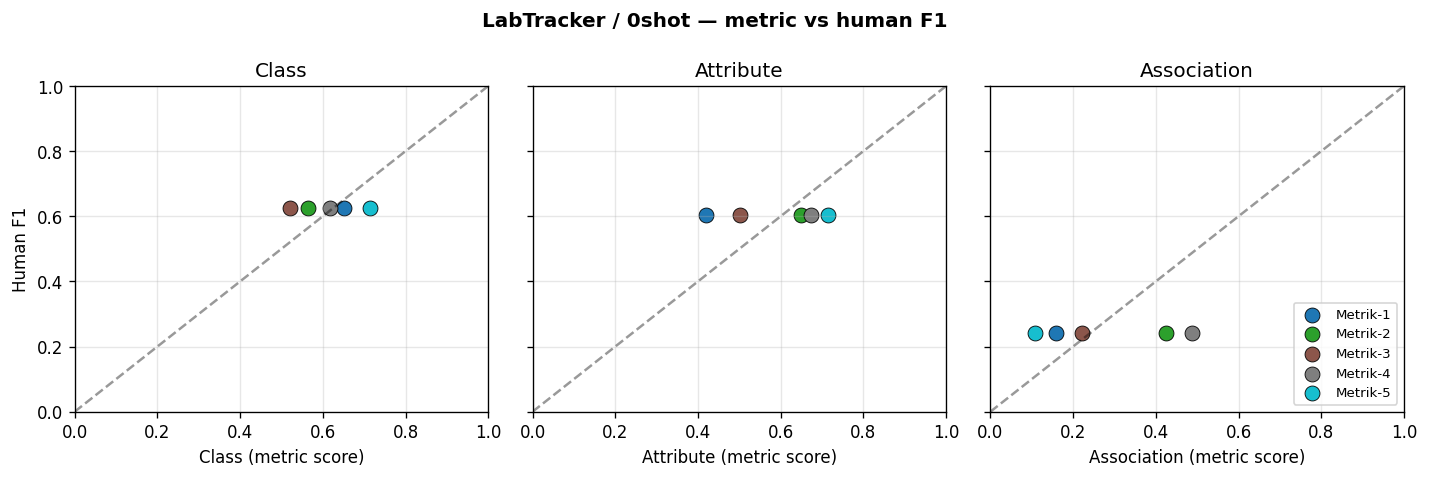

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
elements = ["class_score", "attribute_score", "association_score"]
elem_labels = ["Class", "Attribute", "Association"]
colors = plt.cm.tab10(np.linspace(0, 1, len(df)))
for ax, elem, elabel in zip(axes, elements, elem_labels):
    for (name, row), color in zip(df.iterrows(), colors):
        ax.scatter(row[elem], human[elabel], color=color, s=80, label=name, edgecolor="black", linewidth=0.5)
    ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel(f"{elabel} (metric score)")
    ax.set_title(elabel)
    ax.grid(":", alpha=0.3)
axes[0].set_ylabel("Human F1")
axes[2].legend(loc="lower right", fontsize=8)
fig.suptitle("LabTracker / 0shot — metric vs human F1", fontweight="bold")
fig.tight_layout()
from IPython.display import Image, display
import io
buf = io.BytesIO()
fig.savefig(buf, format="png", dpi=120, bbox_inches="tight")
plt.close(fig)
buf.seek(0)
display(Image(data=buf.read()))
buf.close()


## 7. Cross-metric comparison (full dataset)

The `metrics_comparison.json` file produced by `compare_metrics.py` summarises the 39-pair
performance of each metric. **MAD** = mean |metric_score − human_f1|; lower is better.


In [10]:
comp = json.loads((RESULTS_DIR / "metrics_comparison.json").read_text())
summary = pd.DataFrame(comp).T
cols = ["mad_class_delta_f1", "mad_attribute_delta_f1", "mad_association_delta_f1", "mad_overall_delta"]
summary[cols].round(4).sort_values("mad_overall_delta")


,mad_class_delta_f1,mad_attribute_delta_f1,mad_association_delta_f1,mad_overall_delta
Metrik-5,0.073827,0.145954,0.25819,0.159324
Metrik-4,0.086622,0.136456,0.274462,0.165846
Metrik-1,0.14706,0.231771,0.130885,0.169906
Metrik-3,0.171992,0.212692,0.125808,0.170164
Metrik-2,0.186739,0.150114,0.183367,0.173406


**Best overall MAD:** `Metrik-5` (= D-Metrik-9-2) with 0.1593.

But the per-element breakdown tells a richer story:
- `Metrik-4` and `Metrik-5` are best on Class and Attribute (semantic WordNet matching helps a lot).
- `Metrik-3` is best on Association (pure structural GED is well-tuned to relation matching).
- `Metrik-1` is the most balanced (rule-based, no NLTK overhead).


In [11]:
best = summary[cols[:-1]].idxmin().to_dict()
for elem, winner in best.items():
    val = summary.loc[winner, elem]
    print(f"  {elem:30s}  →  {winner}  (MAD = {val:.4f})")


  mad_class_delta_f1              →  Metrik-5  (MAD = 0.0738)
  mad_attribute_delta_f1          →  Metrik-4  (MAD = 0.1365)
  mad_association_delta_f1        →  Metrik-3  (MAD = 0.1258)


## 8. The cross-metric MAD histogram

Embedded from `Results/metrics_comparison_histogram.png`. Generated by `compare_metrics.py`.
Each row is a metric; each column is an element type. Bars are bucketed counts of |delta|.
Green = close (|delta| < 0.20), red = far (|delta| ≥ 0.30).


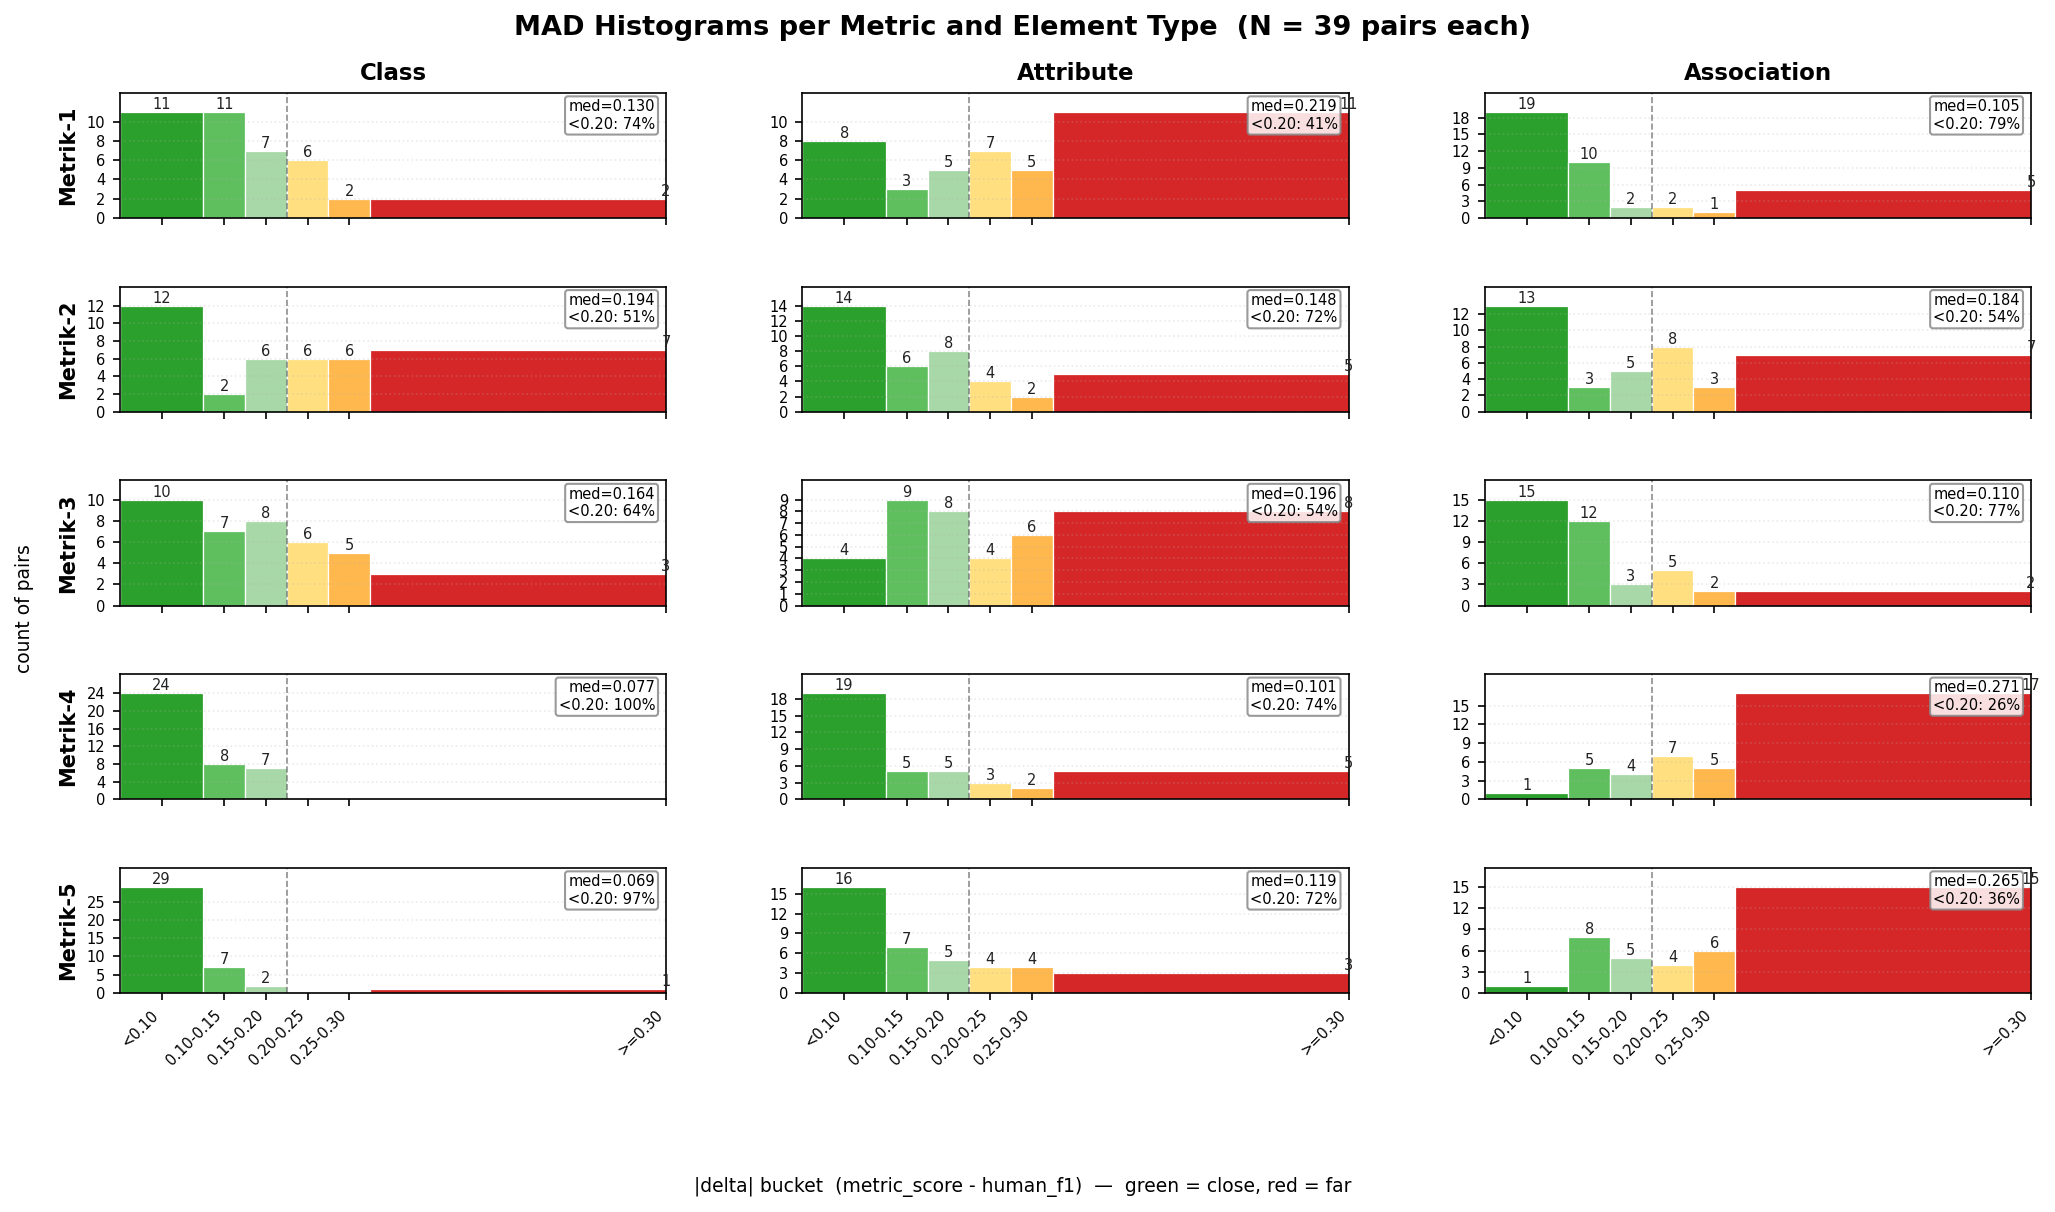

In [12]:
from IPython.display import Image, display

display(Image(filename=str(RESULTS_DIR / "metrics_comparison_histogram.png")))


## 9. Live re-run of all 5 metrics on the example pair (optional)

The cells below re-run all 5 metrics on `LabTracker_0shot` from scratch. This takes ~2 minutes
(the S-1 pipeline of Metrik-4/5 dominates). Set `LIVE = True` to enable.

**Why include this?** To show that each metric can be invoked programmatically, not just batched
via the `RunMetrics/run_metrikN.py` scripts. The code below is the same pattern used by the workflows.


In [13]:
LIVE = False  # set True to re-run all 5 metrics on the example pair (~2 min)

if LIVE:
    from common import metric_paths, setup_sys_path, load_metric_module
    from Workflow import MetricResult

    # ---- Metrik-1 (rule-based) ----
    _, impl_dir = metric_paths(1)
    setup_sys_path(impl_dir)
    m1_mod = load_metric_module(impl_dir)
    from Parser import PlantUMLParser as _Parser
    p = _Parser(strict=True)
    ref = p.parse(example.reference_plantuml)
    gen = p.parse(example.generated_plantuml)
    m1_score = m1_mod.metric(ref, gen)

    # ---- Metrik-2 (graph edit distance) ----
    _, impl_dir = metric_paths(2)
    setup_sys_path(impl_dir)
    m2_mod = load_metric_module(impl_dir)
    m2_score = m2_mod.metric(ref, gen)

    # ---- Metrik-3 (UCG) ----
    _, impl_dir = metric_paths(3)
    setup_sys_path(impl_dir)
    m3_mod = load_metric_module(impl_dir)
    m3_score = m3_mod.metric(ref, gen)

    # ---- Metrik-4 (S-1 v1) ----
    _, impl_dir = metric_paths(4)
    setup_sys_path(impl_dir)
    m4_mod = load_metric_module(impl_dir)
    m4_obj = m4_mod.get_metric()
    m4_score = m4_obj.compute(example.reference_plantuml, example.generated_plantuml)

    # ---- Metrik-5 (S-1 v2) ----
    _, impl_dir = metric_paths(5)
    setup_sys_path(impl_dir)
    m5_mod = load_metric_module(impl_dir)
    m5_obj = m5_mod.get_metric()
    m5_score = m5_obj.compute(example.reference_plantuml, example.generated_plantuml)

    live_results = pd.DataFrame(
        {"Metrik-1": m1_score, "Metrik-2": m2_score, "Metrik-3": m3_score,
         "Metrik-4": m4_score, "Metrik-5": m5_score},
    ).T
    live_results
else:
    print("LIVE = False — using the pre-computed results from section 4.")


LIVE = False — using the pre-computed results from section 4.


## 10. Reproducing everything from scratch

From the project root, in order:

```bash
# (1) Run all 5 metrics over the 39-pair dataset (~40 min wall time on 6 cores).
python3 Quantitative-Analysis/RunMetrics/run_all.py

# (2) Generate the cross-metric comparison table + histogram.
python3 compare_metrics.py

# (3) Re-run this notebook to see the fresh results.
jupyter lab Quantitative-Analysis/Notebooks/comparisons_walkthrough.ipynb
```

The `RunMetrics/run_metrikN.py` scripts write `Quantitative-Analysis/Results/results_metrikN.json`,
and `compare_metrics.py` reads them and writes `metrics_comparison.{json,png}` to the same dir.
Re-running this notebook after the fresh runs will show the new values.


## 11. For the thesis

- The per-metric specifications live in `Metric-Implementation/Metrik-N/Specification/s1.md` (and s2.md where applicable).
- The detailed MAD analysis is in `Results/README.md`.
- The cross-metric comparison rationale and discussion of which metric to prefer is in the dissertation text itself.
- See `../../README.md` for the full project map.
